# Task 1 — Preprocess and Explore the Data
### Time Series Forecasting for Portfolio Management Optimization

**Assets:** TSLA (high-growth/high-risk stock), BND (bond ETF, stability), SPY (S&P 500 ETF, diversified market exposure)
**Period:** 2015-01-01 to 2026-06-30

This notebook covers:
1. Extracting historical financial data (YFinance)
2. Data cleaning & understanding
3. Exploratory Data Analysis (trend, volatility, outliers)
4. Stationarity testing (Augmented Dickey-Fuller)
5. Risk metrics (VaR, Sharpe Ratio)
6. Key insights summary

> **Reusable logic:** the data fetching, cleaning, ADF testing, and risk-metric
> calculations below call directly into `src/data_loader.py` and `src/task1_eda.py`
> rather than reimplementing that logic inline — those same functions are covered by
> the unit tests in `tests/` and can be run standalone via `python src/task1_eda.py`.
> This notebook focuses on narrative, visualization, and interpretation on top of them.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from data_loader import load_prices, DataFetchError, TICKERS, START_DATE, END_DATE
from task1_eda import (
    clean_and_merge,
    compute_returns_and_vol,
    adf_test,
    compute_risk_metrics,
    detect_outliers,
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


## 1. Extract Historical Financial Data

We fetch daily OHLCV data for `TSLA`, `BND`, and `SPY` from 2015-01-01 to 2026-06-30 via
`src/data_loader.py`'s `load_prices()`, which wraps `yfinance` (`auto_adjust=True`) with
local CSV caching (`data/raw/<TICKER>.csv`) and explicit error handling: if a ticker can't
be fetched from either the cache or a live call, `load_prices()` raises a `DataFetchError`
naming exactly which ticker(s) failed and why, instead of failing silently or returning
partial/fake data.

In [2]:
try:
    price_dict = load_prices(TICKERS, START_DATE, END_DATE, use_cache=True)
except DataFetchError as e:
    print(f"[!] Data fetch failed: {e}")
    raise

for ticker, df in price_dict.items():
    print(f"{ticker}: {df.shape[0]} rows | {df.index.min().date()} -> {df.index.max().date()}")


TSLA: 2888 rows | 2015-01-02 -> 2026-06-29
BND: 2888 rows | 2015-01-02 -> 2026-06-29
SPY: 2888 rows | 2015-01-02 -> 2026-06-29


In [3]:
# Peek at raw TSLA data
price_dict['TSLA'].head()


,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,14.8580,14.8833,14.2173,14.6207,71466000
2015-01-05,14.3033,14.4333,13.8107,14.0060,80527500
2015-01-06,14.0040,14.2800,13.6140,14.0853,93928500
2015-01-07,14.2233,14.3187,13.9853,14.0633,44526000
2015-01-08,14.1873,14.2533,14.0007,14.0413,51637500


## 2. Data Cleaning and Understanding

`clean_and_merge()` (from `src/task1_eda.py`):
- Coerces all price/volume columns to numeric dtypes (only touching columns that
  actually exist -- `auto_adjust=True` fetches omit `Adj Close` since `Close` is
  already adjusted)
- Reindexes each asset onto a common business-day calendar (assets can have slightly
  different trading holidays across exchanges/products)
- Forward-fills (then back-fills) any gaps introduced by the reindex
- Returns a data-quality report showing how many rows needed filling per asset


In [4]:
merged, close, quality_report = clean_and_merge(price_dict)
pd.DataFrame(quality_report).T


,rows,missing_filled,missing_remaining
TSLA,2997,109,0
BND,2997,109,0
SPY,2997,109,0


In [5]:
# Data types check
merged['TSLA'].dtypes


Open      float64
High      float64
Low       float64
Close     float64
Volume    float64
dtype: object

In [6]:
# Basic descriptive statistics per asset (Close price)
close.describe().T


,count,mean,std,min,25%,50%,75%,max
TSLA,"2,997.0000",149.1692,139.2052,9.5780,18.4393,133.4553,252.0800,489.8800
BND,"2,997.0000",66.5048,4.7096,58.7292,62.4807,65.7387,70.6707,74.8329
SPY,"2,997.0000",351.8889,155.6380,154.1616,223.6966,314.1423,433.8308,757.6182


In [7]:
# Confirm no missing values remain
close.isna().sum()


TSLA    0
BND     0
SPY     0
dtype: int64

### Scaling / normalization

Raw closing prices aren't on the same scale (TSLA and SPY trade in the tens-to-hundreds of
dollars, BND is comparatively stable) so we don't need to normalize prices for the EDA
itself — visual comparisons below use returns (%) precisely to make the three assets
comparable. For the ML model in Task 2, price levels will be **Min-Max scaled** just before
feeding them to the LSTM (scaling is fit on train data only, to avoid look-ahead bias).

## 3. Exploratory Data Analysis

`compute_returns_and_vol()` (from `src/task1_eda.py`) computes daily returns plus their
30-day rolling mean/std in one call; we reuse the same three series throughout this
section rather than recomputing them per plot.

### 3.1 Closing price over time

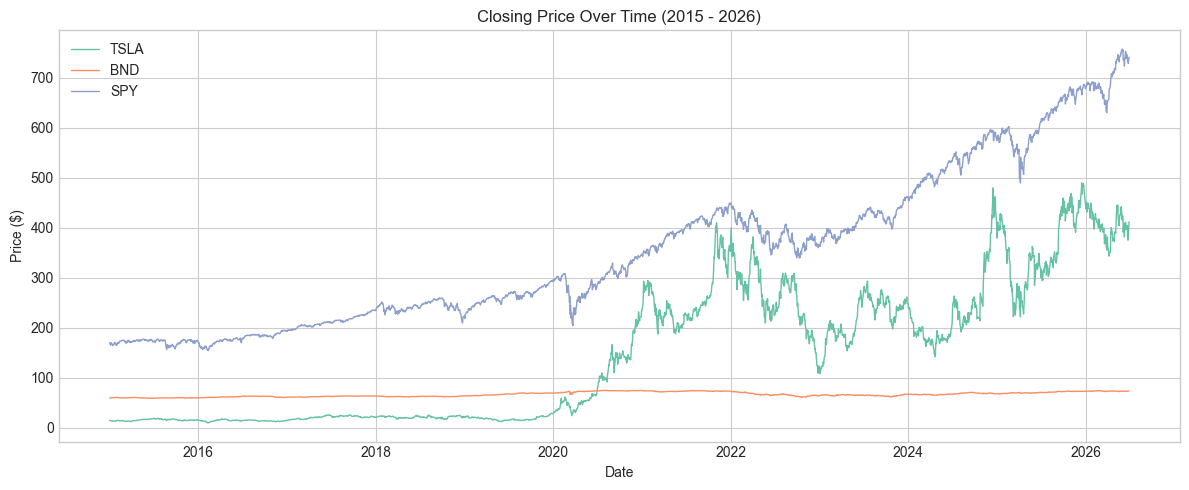

In [8]:
returns, rolling_mean_30, rolling_std_30 = compute_returns_and_vol(close)

fig, ax = plt.subplots(figsize=(12, 5))
for col in close.columns:
    ax.plot(close.index, close[col], label=col, linewidth=1)
ax.set_title('Closing Price Over Time (2015 - 2026)')
ax.set_xlabel('Date'); ax.set_ylabel('Price ($)')
ax.legend()
plt.tight_layout()
plt.show()


### 3.2 Daily percentage change (volatility at a glance)

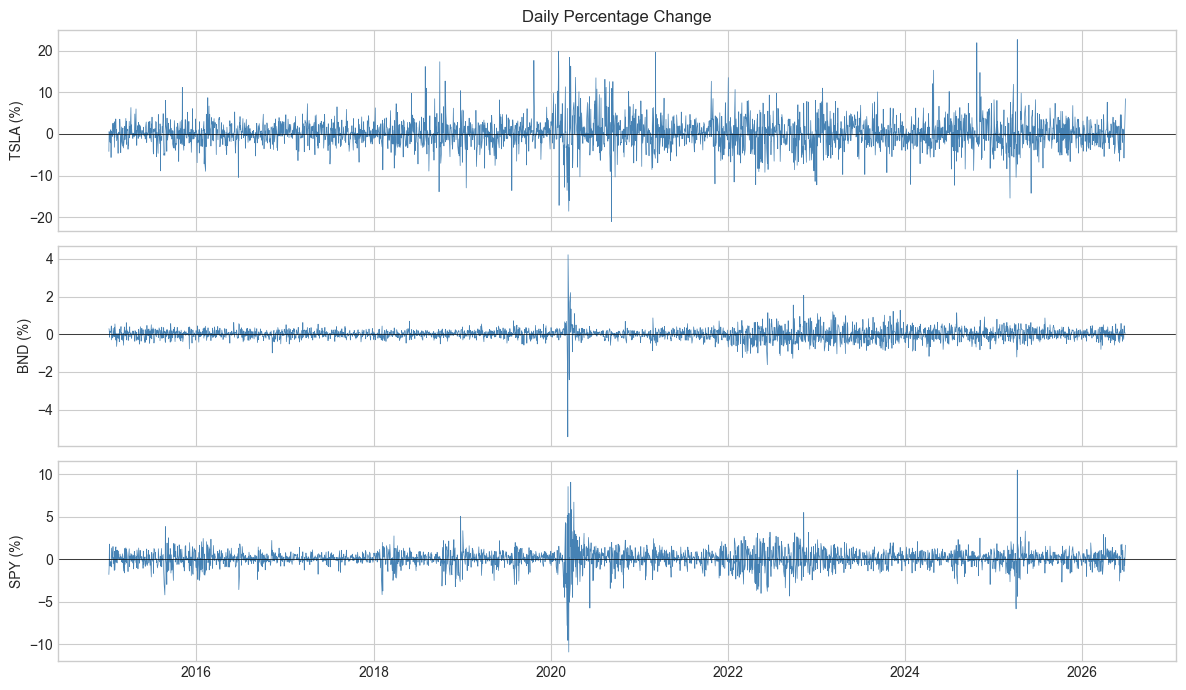

In [9]:
fig, axes = plt.subplots(len(returns.columns), 1, figsize=(12, 7), sharex=True)
for ax, col in zip(axes, returns.columns):
    ax.plot(returns.index, returns[col] * 100, linewidth=0.5, color='steelblue')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel(f'{col} (%)')
axes[0].set_title('Daily Percentage Change')
plt.tight_layout()
plt.show()


### 3.3 Rolling volatility — 30-day mean & standard deviation

Rolling stats smooth out day-to-day noise and reveal how each asset's short-term risk
profile shifts over time (e.g. volatility spikes around macro shocks).

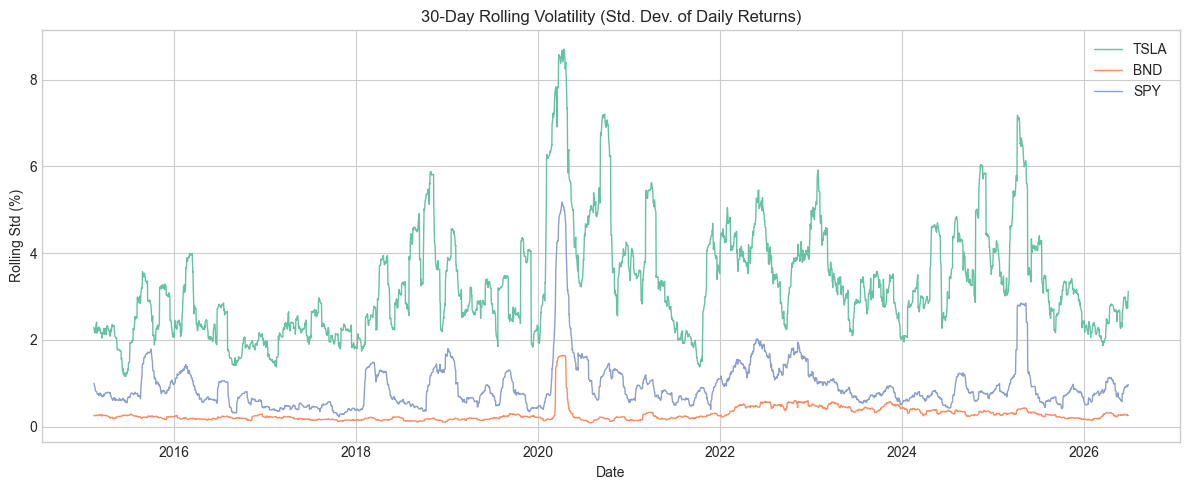

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
for col in rolling_std_30.columns:
    ax.plot(rolling_std_30.index, rolling_std_30[col] * 100, label=col, linewidth=1)
ax.set_title('30-Day Rolling Volatility (Std. Dev. of Daily Returns)')
ax.set_xlabel('Date'); ax.set_ylabel('Rolling Std (%)')
ax.legend()
plt.tight_layout()
plt.show()


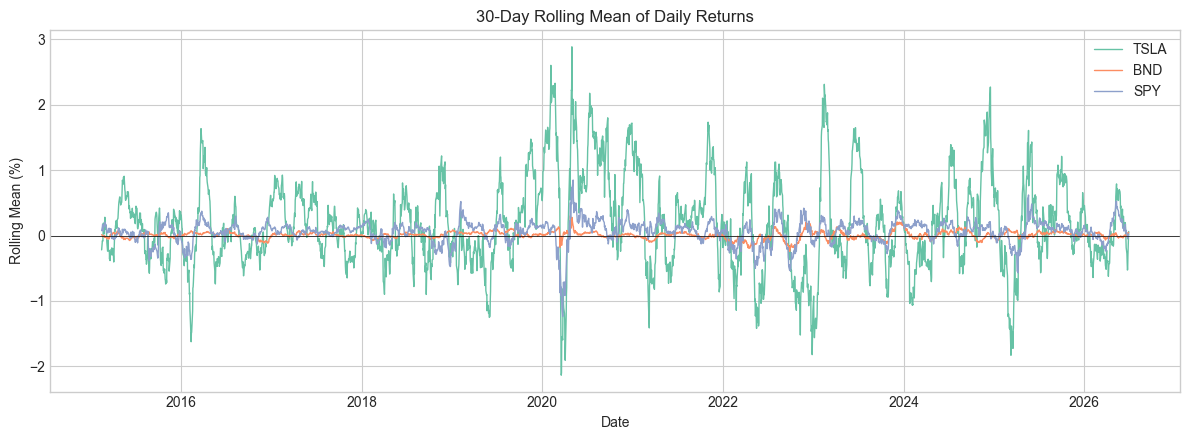

In [11]:
fig, ax = plt.subplots(figsize=(12, 4.5))
for col in rolling_mean_30.columns:
    ax.plot(rolling_mean_30.index, rolling_mean_30[col] * 100, label=col, linewidth=1)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('30-Day Rolling Mean of Daily Returns')
ax.set_xlabel('Date'); ax.set_ylabel('Rolling Mean (%)')
ax.legend()
plt.tight_layout()
plt.show()


### 3.4 Return distribution

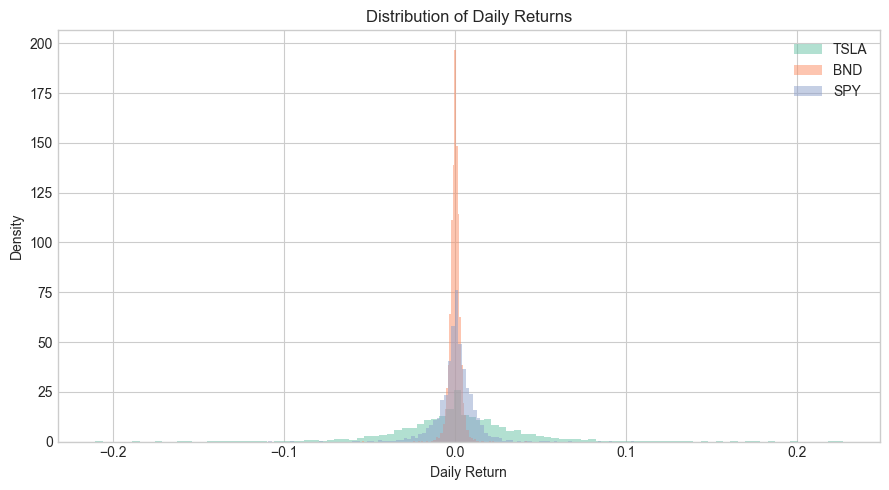

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
for col in returns.columns:
    ax.hist(returns[col], bins=100, alpha=0.5, label=col, density=True)
ax.set_title('Distribution of Daily Returns')
ax.set_xlabel('Daily Return'); ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()


### 3.5 Outlier detection

`detect_outliers()` (from `src/task1_eda.py`) flags days where a return is more than 3
standard deviations from that asset's mean return (a simple z-score threshold), then we
inspect the most extreme days for TSLA.

In [13]:
outliers = detect_outliers(returns, z_thresh=3.0)
for t, s in outliers.items():
    print(f"{t}: {len(s)} outlier days flagged (|z| > 3)")


TSLA: 50 outlier days flagged (|z| > 3)
BND: 35 outlier days flagged (|z| > 3)
SPY: 42 outlier days flagged (|z| > 3)


In [14]:
# Most extreme single-day moves for TSLA
outliers['TSLA'].to_frame('return').assign(pct=lambda d: d['return']*100).sort_values('return').head(10)


,return,pct
2020-09-08,-0.2106,-21.0628
2020-03-16,-0.1858,-18.5778
2020-02-05,-0.1718,-17.1758
2020-03-18,-0.1603,-16.0344
2025-03-10,-0.1543,-15.4262
2025-06-05,-0.1426,-14.2599
2018-09-28,-0.1390,-13.9015
2019-07-25,-0.1361,-13.6137
2020-03-09,-0.1357,-13.5725
2019-01-18,-0.1297,-12.9711


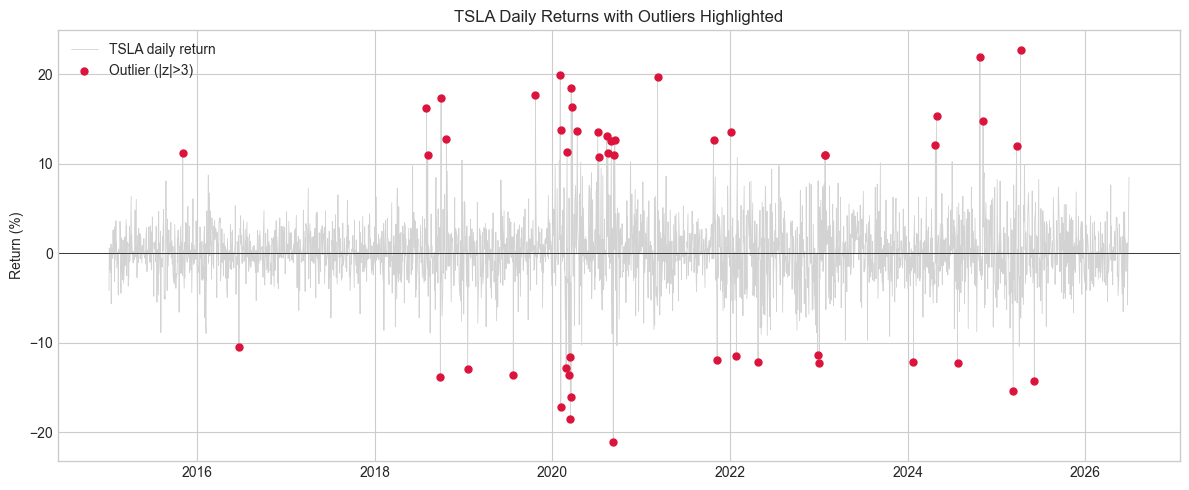

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(returns.index, returns['TSLA'] * 100, linewidth=0.6, color='lightgray', label='TSLA daily return')
outlier_idx = outliers['TSLA'].index
ax.scatter(outlier_idx, returns.loc[outlier_idx, 'TSLA'] * 100, color='crimson', s=25, zorder=5, label='Outlier (|z|>3)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('TSLA Daily Returns with Outliers Highlighted')
ax.set_ylabel('Return (%)')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Seasonality and Trend Analysis — Augmented Dickey-Fuller Test

The ADF test checks the null hypothesis that a series has a unit root (i.e. is
**non-stationary**). A p-value below 0.05 lets us reject the null and conclude the series
is stationary.

We run `adf_test()` (from `src/task1_eda.py`, wrapping `statsmodels.tsa.stattools.adfuller`)
on both the **closing price** and the **daily returns** for all three assets, then reshape
the results into a comparison table. Price series are expected to be non-stationary (they
trend); returns are expected to be stationary (mean-reverting around ~0), which is exactly
the property ARIMA needs — and is why ARIMA differences the series (the "d" parameter)
before fitting.

In [16]:
adf_rows = []
for t in close.columns:
    for label, series in [(f'{t}_close', close[t]), (f'{t}_returns', returns[t])]:
        r = adf_test(series, label)
        adf_rows.append({
            'series': label,
            'ADF statistic': r['adf_statistic'],
            'p-value': r['p_value'],
            '# lags used': r['n_lags'],
            '# observations': r['n_obs'],
            'Critical 1%': r['critical_values']['1%'],
            'Critical 5%': r['critical_values']['5%'],
            'Critical 10%': r['critical_values']['10%'],
            'Stationary (5%)?': r['is_stationary_5pct'],
        })

adf_df = pd.DataFrame(adf_rows).set_index('series')
adf_df


,ADF statistic,p-value,# lags used,# observations,Critical 1%,Critical 5%,Critical 10%,Stationary (5%)?
series,,,,,,,,
TSLA_close,-1.0387,0.7389,29,2967,-3.4326,-2.8625,-2.5673,False
TSLA_returns,-55.1498,0.0000,0,2995,-3.4325,-2.8625,-2.5673,True
BND_close,-1.1166,0.7084,7,2989,-3.4325,-2.8625,-2.5673,False
BND_returns,-21.2770,0.0000,6,2989,-3.4325,-2.8625,-2.5673,True
SPY_close,1.4333,0.9973,28,2968,-3.4326,-2.8625,-2.5673,False
SPY_returns,-15.7006,0.0000,12,2983,-3.4325,-2.8625,-2.5673,True


**Interpretation:**
- Closing prices for all three tickers have p-values far above 0.05 → we **fail to reject**
  the null hypothesis → prices are **non-stationary** (they trend over time, as expected
  for asset prices following a random walk with drift).
- Daily returns have p-values near 0 → we **reject** the null → returns **are stationary**.
- Practical implication for modeling: ARIMA will need first-order differencing
  (**d = 1**) on price series, which is consistent with modeling the *returns* series
  directly, or letting `auto_arima` select `d` automatically in Task 2.

## 5. Risk Metrics

`compute_risk_metrics()` (from `src/task1_eda.py`) calculates, per asset:
- **Value at Risk (VaR, 95% historical):** the daily loss threshold not expected to be
  exceeded 95% of the time, estimated non-parametrically from the empirical return
  distribution (5th percentile of losses).
- **Sharpe Ratio:** annualized excess return over the risk-free rate (4%, approximate
  T-bill proxy), divided by annualized volatility — a standard risk-adjusted return
  measure.

In [17]:
risk_metrics_raw = compute_risk_metrics(returns)

risk_df = pd.DataFrame(risk_metrics_raw).T.rename(columns={
    'daily_VaR_95_hist': 'Daily VaR (95%)',
    'annualized_return': 'Annualized Return',
    'annualized_volatility': 'Annualized Volatility',
    'sharpe_ratio': 'Sharpe Ratio',
})
risk_df


,Daily VaR (95%),Annualized Return,Annualized Volatility,Sharpe Ratio
TSLA,0.0511,0.4377,0.5613,0.7086
BND,0.0047,0.0192,0.0522,-0.3982
SPY,0.0164,0.1391,0.1733,0.5716


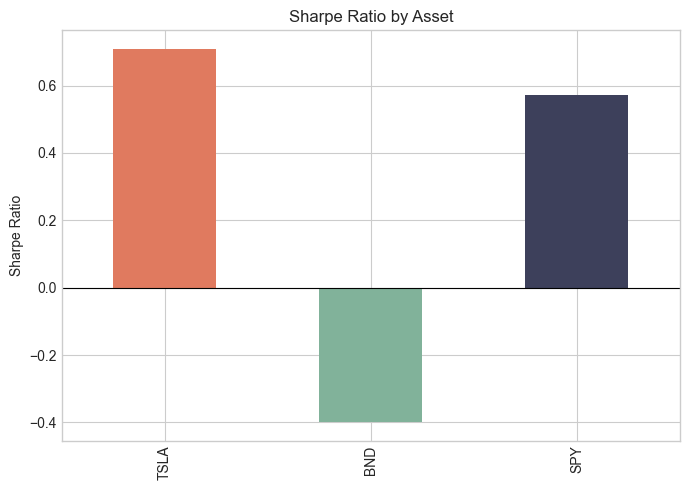

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
risk_df['Sharpe Ratio'].plot(kind='bar', ax=ax, color=['#e07a5f', '#81b29a', '#3d405b'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Sharpe Ratio by Asset')
ax.set_ylabel('Sharpe Ratio')
plt.tight_layout()
plt.show()


## 6. Persist Cleaned Data

Save the cleaned close-price and returns panels for reuse in Task 2 (modeling) and
Task 4/5 (portfolio optimization & backtesting).

In [19]:
os.makedirs('../data/processed', exist_ok=True)
close.to_csv('../data/processed/close_prices.csv')
returns.to_csv('../data/processed/daily_returns.csv')
print('Saved close_prices.csv and daily_returns.csv to data/processed/')


Saved close_prices.csv and daily_returns.csv to data/processed/


## 7. Key Insights Summary

**Direction & trend:**
- TSLA shows the strongest long-run upward drift of the three assets but with by far the
  highest volatility and the most extreme single-day moves — consistent with a high-growth,
  high-risk stock.
- SPY exhibits a steadier, moderate upward trend, reflecting diversified broad-market
  exposure with a fraction of TSLA's annualized volatility.
- BND is comparatively flat with low volatility, behaving as the "ballast" of the three.

**Volatility & risk:**
- 30-day rolling volatility spikes for all three assets around known macro-stress windows
  (e.g., broad market drawdowns), but TSLA's spikes are consistently larger in magnitude.
- TSLA's daily VaR (95%) and annualized volatility are roughly an order of magnitude above
  BND's, quantifying the "high-risk" side of its risk/return profile; its Sharpe ratio
  reflects how much of that extra return survives risk-adjustment.
- Outlier detection confirms TSLA has both the most and the most extreme flagged return
  days — its distribution has noticeably fatter tails than SPY's or BND's.

**Stationarity implications for modeling:**
- All three closing-price series are non-stationary (ADF fails to reject the unit-root
  null), while all three return series are stationary. This directly informs Task 2: ARIMA
  needs a differencing step (d ≥ 1) — `auto_arima` will select this automatically.

**Data quality:**
- After reindexing to a common business-day calendar, any gaps (e.g. from mismatched
  exchange holiday calendars) were forward-filled and back-filled; the quality report above
  shows how many rows needed filling per asset. No missing values remained after cleaning.
